In [1]:
import pandas as pd

import re

# Data Cleaning

I collaborated with ChatGPT and Claude to clean up my edgelist. Since I already crawled the internet, it was able to just use my JSON data rather than crawl a thousand websites. Much faster I got good results this way. I can now use this approach to expand into any location in the world.

In [2]:
data = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\turkey_edgelist_20260813.csv'

df = pd.read_csv(data)
df.dropna(inplace=True)
df

,domain,page_title,linked_domains
0,E-sportsturkey.com,EsporTranker - Espor Bahisleri iÃ§in Eksiksiz ...,esportranker-rs.com
1,blockchaineconomy.istanbul,Blockchain Economy Istanbul Summit,mexc.com
2,esportsbetting-ua.com,EsporTranker - ÐÐ°Ñ Ð¿Ð¾Ð²Ð½Ð¸Ð¹ Ð¿Ð¾ÑÑÐ±Ð...,e-sportsturkey.com
3,worldfood-istanbul.com,WorldFood Istanbul 2026,foodsektor.com
5,petfuari.com,PETZOO Eurasia | Türkiye’nin En Büyük Evcil Ha...,globalpetindustry.com
...,...,...,...
1566,E-sportsturkey.com,EsporTranker - Espor Bahisleri iÃ§in Eksiksiz ...,esportbetting-id.com
1567,e-sportsturkey.com,EsporTranker - Espor Bahisleri iÃ§in Eksiksiz ...,esportbetting.it
1568,E-sportsturkey.com,EsporTranker - Espor Bahisleri iÃ§in Eksiksiz ...,esportswetten.at
1569,erotickeinzeraty.sk,"Sex inzeráty, sex ponuky, sex priváty, sex zoz...",callgirlsturkey.com


In [3]:
# I will use this for my filtering and to understand the scale. i am not going to show the results. 
# there are so many adult websites, and that has been true since day one of the internet
# if you do OSINT, you typically want to filter them out
junk_mask = df['page_title'].str.contains('porn|sex|jav|singles|dating|escort|hentai|voyeur|naked|xxx|adult|blocked', case=False)

junk_df = df[junk_mask]
junk_df.shape

(171, 3)

In [4]:
df = df[~junk_mask].copy() # if you want the opposite of the filter, then you use the ~ mark
df.head()

,domain,page_title,linked_domains
0,E-sportsturkey.com,EsporTranker - Espor Bahisleri iÃ§in Eksiksiz ...,esportranker-rs.com
1,blockchaineconomy.istanbul,Blockchain Economy Istanbul Summit,mexc.com
2,esportsbetting-ua.com,EsporTranker - ÐÐ°Ñ Ð¿Ð¾Ð²Ð½Ð¸Ð¹ Ð¿Ð¾ÑÑÐ±Ð...,e-sportsturkey.com
3,worldfood-istanbul.com,WorldFood Istanbul 2026,foodsektor.com
5,petfuari.com,PETZOO Eurasia | Türkiye’nin En Büyük Evcil Ha...,globalpetindustry.com


In [5]:
df.shape

(1349, 3)

In [7]:
# title_filter = (
#     # English
#     'live music|concert|concerts|music festival|music festivals|music venue|music hall|'
#     'live performance|open mic|jam session|musician|musicians|'
#     'rock music|rock band|rock bands|rock festival|rock concert|'
#     'jazz|punk|metal|blues|folk|acoustic|nightlife|'
#     'performing arts|theatre|theater|orchestra|'
#     'opera house|opera festival|opera company|'
#     'dj set|dj sets|dj music|dj night|'
#     'local music|local artist|local artists|community music|music calendar|concert calendar|'

#     # German
#     'livemusik|live musik|konzert|konzerte|musikfestival|musikfestivals|'
#     'musikclub|musikhalle|konzerthalle|veranstaltungskalender|'
#     'musiker|jazz|punk|metal|blues|akustik|'
#     'rockmusik|rockband|rockfestival|rockkonzert|'
#     'theater|orchester|musikschule|musikverein|innenhofkonzerte|'
#     'opernhaus|opernfestival|'

#     # French
#     'musique live|musique en direct|concert|concerts|festival de musique|'
#     'salle de concert|salle de musique|musicien|musiciens|groupe de musique|'
#     'jazz|punk|metal|blues|acoustique|'
#     'rock musique|groupe de rock|festival rock|concert rock|'
#     'spectacle vivant|théâtre|orchestre|'
#     'opéra national|festival d’opéra|maison d’opéra|'

#     # Spanish
#     'música en vivo|musica en vivo|concierto|conciertos|festival de música|festival de musica|'
#     'sala de conciertos|sala de música|sala de musica|músico|musico|músicos|musicos|'
#     'jazz|punk|metal|blues|acústico|acustico|'
#     'música rock|musica rock|banda de rock|festival de rock|concierto de rock|'
#     'teatro|orquesta|'
#     'teatro de ópera|teatro de opera|festival de ópera|festival de opera|'

#     # Italian
#     'musica dal vivo|concerto|concerti|festival musicale|festival di musica|'
#     'locale di musica|locale musica|sala concerti|musicista|musicisti|'
#     'jazz|punk|metal|blues|acustico|'
#     'musica rock|rock band|festival rock|concerto rock|'
#     'teatro|orchestra|'
#     'teatro dell’opera|teatro dell opera|festival lirico|festival opera|'

#     # Dutch
#     'live muziek|concert|concerten|muziekfestival|muziekfestivals|'
#     'muziekpodium|muziekzaal|concertzaal|muzikant|muzikanten|'
#     'jazz|punk|metal|blues|akoestisch|'
#     'rockmuziek|rockband|rockfestival|rockconcert|'
#     'theater|orkest|'
#     'operahuis|operafestival|'

#     # Swedish
#     'livemusik|konsert|konserter|musikfestival|musikfestivaler|'
#     'musikscen|konserthus|musiker|'
#     'jazz|punk|metal|blues|akustisk|'
#     'rockmusik|rockband|rockfestival|rockkonsert|'
#     'teater|orkester|'
#     'operahus|operafestival|'

#     # Polish
#     'muzyka na żywo|koncert|koncerty|festiwal muzyczny|festiwale muzyczne|'
#     'klub muzyczny|sala koncertowa|muzyk|muzycy|zespół muzyczny|'
#     'jazz|punk|metal|blues|akustyczny|'
#     'muzyka rockowa|zespół rockowy|festiwal rockowy|koncert rockowy|'
#     'teatr|orkiestra|'
#     'opera narodowa|festiwal operowy|'

#     # Czech
#     'živá hudba|ziva hudba|koncert|koncerty|hudební festival|hudebni festival|'
#     'hudební klub|hudebni klub|koncertní sál|koncertni sal|hudebník|hudebnici|kapela|'
#     'jazz|punk|metal|blues|akustická hudba|'
#     'rocková hudba|rockova hudba|rocková kapela|rockovy festival|rockový koncert|'
#     'divadlo|orchestr|'
#     'operní dům|operni dum|operní festival|operni festival|'

#     # Turkish
#     'canlı müzik|canli muzik|konser|konserler|müzik festivali|muzik festivali|'
#     'müzik mekanı|muzik mekani|konser salonu|müzisyen|muzisyen|'
#     'müzik grubu|muzik grubu|açık mikrofon|acik mikrofon|jam session|'
#     'yerel müzik|yerel muzik|yerel sanatçı|yerel sanatci|'
#     'caz|punk|metal|blues|akustik|'
#     'rock müzik|rock muzik|rock grubu|rock festivali|rock konseri|'
#     'tiyatro|orkestra|'
#     'opera binası|opera binasi|opera festivali|'

#     # Japanese
#     'ライブハウス|ライブ音楽|生演奏|コンサート|演奏会|音楽祭|'
#     '音楽フェス|ライブイベント|コンサートホール|音楽ホール|'
#     'ミュージシャン|バンド|歌手|シンガー|'
#     'ジャズ|ロック|パンク|メタル|ブルース|アコースティック|'
#     'オープンマイク|ジャムセッション|'
#     '劇場|演劇|オペラハウス|オペラ公演|オーケストラ'
# )

# check_df = df[df['page_title'].str.contains(title_filter, case=False, na=False)]
# check_df.shape

In [9]:
titles = sorted(df['page_title'].value_counts().index.values)
titles

['- Insightful Perspectives, Powerful Narratives',
 "2026 'deki En Ä°yi Mobil Casino UygulamalarÄ± | CasinoRank",
 "2026'te Ã§evrimiÃ§i olan En Ä°yi Piyango Siteleri ð\x9f\x8f\x86",
 '2gms1mic.com is for sale',
 'AML Consulting & Compliance Services Canada',
 'AQUATIC ANIMAL ALLIANCE',
 'AVPN - Associazione Verace Pizza Napoletana',
 'Accueil - Oumnia Rénovation',
 'Acibadem Hospitals Group | Leading Hospitals In Turkey',
 'Adana Mersin - Adana | Mersin',
 'AffPapa.com - iGaming directory for Affiliates and Operators',
 'Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursaspor Yorumcusu',
 'Alpha Capital - Unleash the Alpha in Crypto',
 'Ambasciata Di Türkiye Ufficio Cultura e Informazioni - Ambasciata Di Turchia Ufficio Cultura e Informazioni',
 'Amcham Turkey – AmCham Turkiye is a business association comprised of 110+ prominent U.S. companies with operations in Turkey',
 'Amchams in Europe – The VOICES of International Business in Europe',
 'Ana Sayfa | Türkiye Fintek Derneği',
 'Anasayfa

In [11]:
title_file = r'C:\Users\itsgo\OneDrive\Desktop\expansion\keeper_domain_titles.txt'

# doing it this way to keep titles that have columns without screwing up the read_csv
with open(title_file, 'r', encoding='utf-8') as f:
    titles = [line.strip() for line in f if line.strip()]

keep_df = pd.DataFrame({'page_title': titles})

keep_df.head()

,page_title
0,"- Insightful Perspectives, Powerful Narratives"
1,Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursa...
2,Ambasciata Di Türkiye Ufficio Cultura e Inform...
3,Ankara Yaşam - Ankara Yaşam Rehberi | Etkinlik...
4,ArabRailNews - السكك الحديدية | النقل | الخدما...


In [12]:
keepers_df = keep_df.merge(df, on='page_title', how='left')
keepers_df.drop_duplicates(inplace=True)
keepers_df.head()

,page_title,domain,linked_domains
0,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,tr.mertking-turkiye2026.net
1,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,ankaraihlasnakliyat.com.tr
2,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,bayanankara.com
3,Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursa...,ahmeteminyilmaz.com,ankarayasam.com
4,Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursa...,ahmeteminyilmaz.com,rayturkiye.com


In [13]:
fails_df = keepers_df[keepers_df['domain'].isna()]
failed_titles = fails_df['page_title'].tolist()

pattern = '|'.join(re.escape(title) for title in failed_titles)

fail_capture_df = df[df['page_title'].str.contains(pattern, case=False, na=False)].copy()
fail_capture_df.dropna(inplace=True)
fail_capture_df.drop_duplicates(inplace=True)
fail_capture_df.shape

(1349, 3)

In [15]:
final_df = pd.concat([keepers_df, fail_capture_df], ignore_index=True)
final_df.dropna(inplace=True)
final_df.columns = ['page_title', 'domain', 'linked_domain']

final_df['domain'] = final_df['domain'].str.lower()
final_df['linked_domain'] = final_df['linked_domain'].str.lower()

drop_pattern = 'store'

final_df = final_df[
    ~final_df['domain'].str.contains(drop_pattern, na=False) &
    ~final_df['linked_domain'].str.contains(drop_pattern, na=False)
]

junk_domains = (
    'facebook.com|instagram.com|youtube.com|twitter.com|x.com|'
    'tiktok.com|linkedin.com|bsky.app|reddit.com|threads.net|google.com|amazon.com'
)

final_df = final_df[
    ~final_df['domain'].str.contains(junk_domains, na=False) &
    ~final_df['linked_domain'].str.contains(junk_domains, na=False)
]

final_df.drop_duplicates(inplace=True)

final_df.head()

,page_title,domain,linked_domain
0,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,tr.mertking-turkiye2026.net
1,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,ankaraihlasnakliyat.com.tr
2,"- Insightful Perspectives, Powerful Narratives",indiaviewpoint.com,bayanankara.com
3,Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursa...,ahmeteminyilmaz.com,ankarayasam.com
4,Ahmet Emin Yilmaz - Bursa Köşe Yazarı ve Bursa...,ahmeteminyilmaz.com,rayturkiye.com


In [16]:
data= r'C:\Users\itsgo\OneDrive\Desktop\verdant\websites.csv'

crawl_df = pd.read_csv(data, header=None)
crawl_df.columns = ['domain']
crawl_domains = sorted(set(crawl_df['domain'].values))
len(crawl_domains)

10610

In [17]:
# all domains are keepers
keeper_domains = sorted(set(final_df['domain'].unique()))

keeper_domains = [k for k in keeper_domains if k not in crawl_domains]
print(len(keeper_domains))
#keeper_domains

342


In [18]:
# all linked_domains are candidates for expansion

In [19]:
candidate_domains = (
    final_df['linked_domain']
    .dropna()
    .drop_duplicates()
)

candidate_domains = candidate_domains[
    ~candidate_domains.isin(keeper_domains)
]

candidate_domains = [c for c in sorted(set(candidate_domains)) if c not in crawl_domains]

len(candidate_domains)

425

In [20]:
# extra domains found in linked_domains

In [20]:
candidate_domains

['1ci.com',
 '2014.istanbultechtalks.com',
 'aaxo.co.za',
 'acad.ro',
 'acadsudest.ro',
 'acibadem.edu.tr',
 'acibademhealthpoint.com',
 'ada.net.tr',
 'adlnk.cn',
 'adria-ankaran.si',
 'aeo.org.uk',
 'agapanthusrising.com',
 'ame1a56mb.com',
 'anadoluslotwin.com',
 'animationdingle.com',
 'ankaradershane.com.tr',
 'ankaradershanefiyatlari.com.tr',
 'ankaraihlasnakliyat.com.tr',
 'ankaran.sportifiq.com',
 'ankarasolar.com.tr',
 'antoine-merle.com',
 'api.whatsapp.com',
 'app-eu.readspeaker.com',
 'apps.apple.com',
 'apuestasesports.com.ar',
 'apuestasesports.com.py',
 'apuestasesports.com.ve',
 'areon.network',
 'arnes.si',
 'arongroups.co',
 'articulacaoconservadora.org',
 'asyamedya.net',
 'avrora-token.com',
 'azfina.az',
 'b2binpay.com',
 'b2broker.com',
 'balkankaravan.ch',
 'bayanankara.com',
 'bcngarden.io',
 'be7proje.com',
 'begambleaware.org',
 'behance.net',
 'beinwonfk.com',
 'bestimage.com.tr',
 'big-help.info',
 'big5constructegypt.com',
 'big5constructethiopia.com',
 'bi

In [22]:
data = r'C:\Users\itsgo\OneDrive\Desktop\candidate_keeper_linked_domains.csv'

candidate_keepers = pd.read_csv(data, header=None)
candidate_keepers.columns = ['domain']
candidate_keeper_domains = sorted(set(candidate_keepers['domain'].values))
candidate_keeper_domains[0:5]

['abc.net.au', 'acllive.com', 'advocate.com', 'aei.org', 'aerospace.org']

In [23]:
final_expansion_domain_set = sorted(set(keeper_domains + candidate_keeper_domains))
len(final_expansion_domain_set)

1845

In [24]:
#[print(d) for d in final_expansion_domain_set]

# Graph Analysis

My goal is to identify several websites that talk about aspects of life in Japan, including but not limited to music, art, and events. Mainly, I want to remove junk and see what is left that may be useful as a source of information. Then I will inspect closer once I have an overall map.

In [21]:
import networkx as nx
import numpy as np
import pandas as pd

# for the explode statement; convert string to list
from ast import literal_eval

# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

In [22]:
G = nx.from_pandas_edgelist(final_df, 'domain', 'linked_domain')
print(G)

Graph with 785 nodes and 878 edges


In [23]:
#draw_graph(G, edge_width=0.1, node_size=3)

I originally used my pre-LLM graph methods, but then I had an idea to save a lot of time, so collaborated with AI (Claude and ChatGPT) to filter the edgelist directly rather than crawling hundreds of websites. I already did that for them, which made the collaboration a lot faster.

I am hunting for 1) news, 2) music, 3) art, 4) cultural informaiton, 5) event information, 6) other information families use.

Let's use Page Rank and Egocentric Network Analysis to zoom in with our Graph Microscope. :)

In [24]:
[n for n in sorted(G.nodes) if 'city' in n.lower()] # other city nodes

[]

In [152]:
# keywords = ['music', 'art', 'community']

# [n for n in sorted(G.nodes) if any(kw in n.lower() for kw in keywords)]

# Page Rank Analysis

Let's see what Page Rank thinks are the most important nodes in the graph.

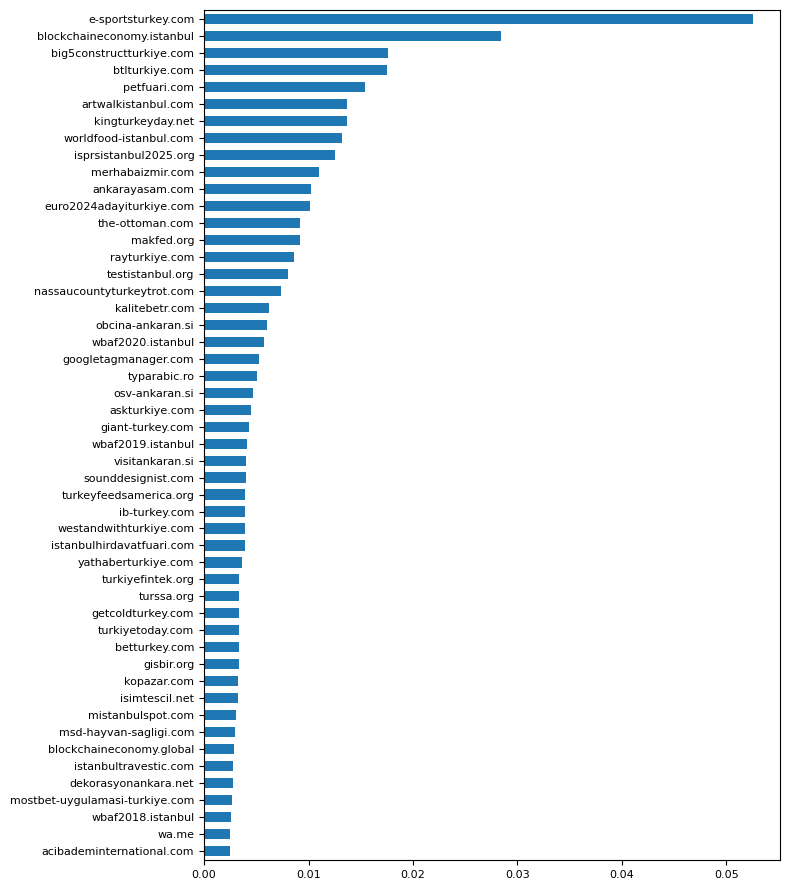

In [25]:
import matplotlib.pyplot as plt

top_domains = pd.Series(nx.pagerank(G)).sort_values(ascending=False)[:50]
top_domains[::-1].plot.barh(figsize=(8, 9), width=0.6, fontsize=8)
plt.tight_layout()

In [26]:
def draw_ego(G, center, radius=1, node_size=4, show_names=True):

    ego = nx.ego_graph(G, center, radius=radius)

    for domain in sorted(ego.nodes):
        print(domain)
        
    return draw_graph(ego, node_size=node_size, show_names=show_names)

In [27]:
# draw_ego(G, top_domains.index[0])